# 1. Install necessary Libraries
In this part, we'll begin by installing necessary libraries needed for running our computer vision training and testing scripts\
**(NOTE): NO NEED TO RERUN THIS CELL EVEN IF SERVER RESTARTS**, as the libraries are stored inside VM boot disk and will not be removed

In [30]:
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128
%pip install transformers scikit-learn pillow pandas numpy matplotlib huggingface_hub ipywidgets opencv-python google-cloud-storage

Looking in indexes: https://download.pytorch.org/whl/cu128
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# 2. Download Dataset From Storage Bucket to Jupyter Server
This is to reduce continuous Read/Write Call from Storage Bucket and reduce cost.\
**(Note): RUN THIS CELL ONCE ONLY EVEN IF SERVER RESTARTS.** This is because the dataset is stored locally in Jupyter Server and will remain even if server restart.\
Running multiple times may result in the 4939 images downloaded multiple times

In [ ]:
from google.cloud import storage
import os

client = storage.Client()
bucket = client.bucket('naic-dataset-images')

# 1. Create the local directory
os.makedirs('dataset/image', exist_ok=True)

# 2. Download labels.csv permanently to the local disk
print("Fetching labels.csv...")
blob_csv = bucket.blob('labels.csv')
# Save it locally instead of holding it in memory
blob_csv.download_to_filename('dataset/labels.csv')
print("✅ labels.csv saved to dataset/labels.csv")

# 3. Download the images
blobs = bucket.list_blobs(prefix='image/')
print("\nStarting image download...")

download_count = 0
for i, blob in enumerate(blobs):
    if not blob.name.endswith('/'):
        filename = blob.name.split('/')[-1]
        local_path = f'dataset/image/{filename}'

        # Only download if the file isn't already on the disk
        if not os.path.exists(local_path):
            blob.download_to_filename(local_path)
            download_count += 1

    if i % 500 == 0:
        print(f"Scanned {i} files...")

print(f"✅ Download complete! Fetched {download_count} new images. L4 GPU is ready to work.")

# 3. Read CSV File from Storage Bucket
In this part, since we need to create a variable df using pandas to load the csv file, we should separate this part from downloading part as variable is voilatile and will be reset every time kernel/server restarts

In [32]:
import pandas as pd

# Read the CSV directly from the VM's high-speed local disk
df = pd.read_csv('dataset/labels.csv')

print(f"Ready to train with {len(df)} images on local disk.")

Ready to train with 4939 images on local disk.


# 4. CLAHE Data Preprocessing + Retina Cropping
In this part, we'll write Contrast Limited Adaptive Histogram Equalization (CLAHE) preprocessing function logic, which is used to enhance the blurry dataset images to enable clearer image and allow small pixels to be detected. Besides that, we also implemented retina cropping to determine the eye fundus pixels more accurately

In [33]:
import cv2
import numpy as np
from PIL import Image

def crop_fundus(image, tol=10):
    """
    Removes the useless black borders around the circular fundus image.
    tol: Tolerance for black pixels (values below 10 are considered background).
    """
    if isinstance(image, Image.Image):
        image = np.array(image)

    # Convert to grayscale to easily separate the eye from the background
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    # Create a mask of all pixels brighter than the tolerance
    mask = gray > tol

    # Get the coordinates of the actual eyeball
    coords = np.argwhere(mask)

    # Safety check: if the image is completely black, return the original
    if coords.size == 0:
        return image

    # Find the bounding box (min and max Y, min and max X)
    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0) + 1 # +1 to include the last pixel

    # Crop the image using numpy slicing
    cropped = image[y0:y1, x0:x1]

    return cropped

def preprocess_fundus(image):
    """
    The ultimate medical preprocessing pipeline.
    1. Tight crop the retina.
    2. Apply Green Channel CLAHE.
    """
    # Step 1: Remove black borders
    cropped_img = crop_fundus(image)

    # Step 2: Split into R, G, B channels
    r, g, b = cv2.split(cropped_img)

    # Step 3: Apply Green Channel CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    g_enhanced = clahe.apply(g)

    # Step 4: Merge and return as PIL Image for PyTorch
    enhanced = cv2.merge((r, g_enhanced, b))
    return Image.fromarray(enhanced)

# 5. Preprocessed vs Processed Image Visualization Comparison
In this part, we'll run a script to compare the dataset images before and after preprocessing to see if it's successful and fulfills our requirements

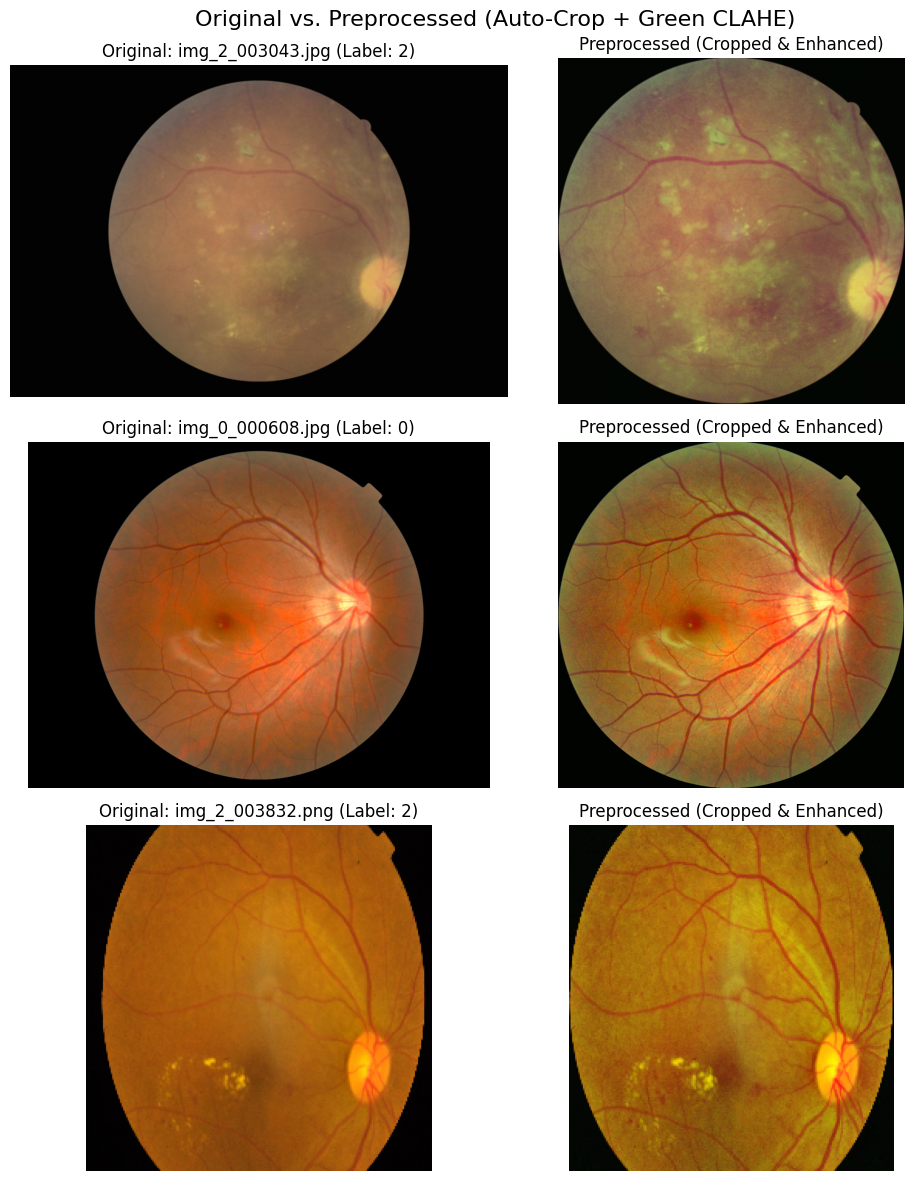

In [34]:
import matplotlib.pyplot as plt

def display_preprocessing_samples(dataframe, img_directory, num_samples=3):
    """
    Randomly samples images from the dataframe and displays a side-by-side
    comparison of the original vs. preprocessed images.
    """
    # Take random samples from the dataframe
    samples = dataframe.sample(n=num_samples)

    fig, axes = plt.subplots(num_samples, 2, figsize=(10, 4 * num_samples))
    fig.suptitle("Original vs. Preprocessed (Auto-Crop + Green CLAHE)", fontsize=16)

    for i, (_, row) in enumerate(samples.iterrows()):
        img_path = os.path.join(img_directory, row['Image'])
        original_img = Image.open(img_path).convert("RGB")

        # Apply the medical preprocessing pipeline
        preprocessed_img = preprocess_fundus(original_img)

        # Plot Original
        axes[i, 0].imshow(original_img)
        axes[i, 0].set_title(f"Original: {row['Image']} (Label: {row['Label']})")
        axes[i, 0].axis('off')

        # Plot Preprocessed
        axes[i, 1].imshow(preprocessed_img)
        axes[i, 1].set_title(f"Preprocessed (Cropped & Enhanced)")
        axes[i, 1].axis('off')

    plt.tight_layout()
    plt.show()

# Run the visualizer (Ensure 'df' and 'dataset/image' are defined in your environment)
display_preprocessing_samples(df, "dataset/image/", num_samples=3)

# 6. Custom Dataset Loader
Since we're using a custom dataset, we will need to write a custom dataset loader to pass our image data to the model


In [35]:
from torch.utils.data import Dataset
from PIL import Image
import os

class MedicalDatasetLoader(Dataset):
    def __init__(self, df, img_dir, transform=None, use_preprocessing=True):
        self.data = df # Differentiate between train_df, val_df and test_df
        self.img_dir = img_dir # Image Directory Path
        self.transform = transform # Data augmentation
        self.use_preprocessing = use_preprocessing # Apply cropping & CLAHE

    def __len__(self):
        return len(self.data) # Calculate the number of rows of the dataset

    def __getitem__(self, idx):
        img_name = self.data.iloc[idx]['Image'] # Get the image name from the csv header
        label = int(self.data.iloc[idx]['Label']) # Get the Label value from csv header

        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert("RGB")

        # 🔥 Call the combined auto-crop and green CLAHE pipeline
        if self.use_preprocessing:
            image = preprocess_fundus(image)

        if self.transform: # Implement Data Augmentation (Resize, Flip, etc.)
            image = self.transform(image)

        return image, label

# 7. Setup Cuda Device
Here in this part, we check if PyTorch detects our GPU cuda cores

In [36]:
import torch

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # Check if cuda is detected by pytorch, fallback to CPU otherwise
print("Cuda available: ", torch.cuda.is_available())

Cuda available:  True


# 8. Setup Model
In this part, we will load the Deep Learning model from huggingface. Remember to change the library imports and pretrain name based on your designated model choice.\
Feel free to design the inner architecture of your model choice such as its layers, activation function types and Feed Forward Network (FFN) layers here as well

In [37]:
from transformers import AutoImageProcessor, EfficientNetForImageClassification

# 1. Define the model variant
model_name = 'google/efficientnet-b4'

# 2. Load EfficientNetB3 with the built-in classification head
# We set num_labels=5 for your retinopathy severity classes
model = EfficientNetForImageClassification.from_pretrained(
    model_name,
    num_labels=5,
    ignore_mismatched_sizes=True # Essential when replacing the ImageNet head with 5 classes
).to(device)

# 3. Load the processor for normalization values
processor = AutoImageProcessor.from_pretrained(model_name)

You passed `num_labels=5` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/706 [00:00<?, ?it/s]

EfficientNetForImageClassification LOAD REPORT from: google/efficientnet-b4
Key               | Status   |                                                                                            
------------------+----------+--------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 1792]) vs model:torch.Size([5, 1792])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([5])            

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


# 9. Data Preprocessing
In this part, we will perform data augmentation on our dataset through torchvision library, then split our dataset into training and validation data.

In [38]:
from torchvision import transforms
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
import pandas as pd

# Data augmentation
train_transform = transforms.Compose([
    transforms.Resize((380, 380)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=processor.image_mean, std=processor.image_std) # We use the model's custom normalization values
])

val_transform = transforms.Compose([ # No data augmentation for val/testing
    transforms.Resize((380, 380)),
    transforms.ToTensor(),
    transforms.Normalize(mean=processor.image_mean, std=processor.image_std)
])

# Step 1: Train+Val / Test
train_val_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['Label'],
    random_state=42
)

test_dataset = MedicalDatasetLoader(test_df, "dataset/image", val_transform, use_preprocessing=False)

test_loader = DataLoader(
    test_dataset,
    batch_size=16, # Adjust this according to the L4 GPU VRAM usage
    shuffle=False,
)
print(f"Test: {len(test_df)}")

Test: 988


# 10. Experiment Logging Class
In this part, we'll create a log class tha can help us to logs our hyperparameter lists as well as result metrics.

In [39]:
import json
from datetime import datetime
import os

class ExperimentTracker:
    def __init__(self, base_dir="experiments"):
        self.base_dir = base_dir
        os.makedirs(base_dir, exist_ok=True)

        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        self.exp_dir = os.path.join(base_dir, f"exp_{timestamp}")
        os.makedirs(self.exp_dir)

        self.epoch_metrics = []
        self.final_metrics = {}
        self.config = {}

    # ---------------- CONFIG ----------------
    def log_config(self, config):
        self.config = config
        with open(os.path.join(self.exp_dir, "config.json"), "w") as f:
            json.dump(config, f, indent=4)

    # 🔥 NEW: Saves state for Spot Instance recovery
    def save_checkpoint(self, fold, epoch, model, optimizer, scheduler, scaler, is_best=False):
        checkpoint = {
            'fold': fold,
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'scaler_state_dict': scaler.state_dict(),
        }
        # Save 'latest' for recovery
        ckpt_path = os.path.join(self.exp_dir, f"checkpoint_fold_{fold}.pth")
        torch.save(checkpoint, ckpt_path)

        if is_best:
            torch.save(model.state_dict(), os.path.join(self.exp_dir, f"best_model_fold_{fold}.pth"))
        print(f"💾 Checkpoint saved at Epoch {epoch+1}")

    # 🔥 NEW: Loads state if the script restarts
    def load_checkpoint(self, fold, model, optimizer, scheduler, scaler):
        ckpt_path = os.path.join(self.exp_dir, f"checkpoint_fold_{fold}.pth")
        if os.path.exists(ckpt_path):
            print(f"🔄 Resuming from checkpoint: {ckpt_path}")
            ckpt = torch.load(ckpt_path)
            model.load_state_dict(ckpt['model_state_dict'])
            optimizer.load_state_dict(ckpt['optimizer_state_dict'])
            scheduler.load_state_dict(ckpt['scheduler_state_dict'])
            scaler.load_state_dict(ckpt['scaler_state_dict'])
            return ckpt['epoch'] + 1 # Start from the next epoch
        return 0

    # ---------------- PER EPOCH ----------------
    def log_epoch(self, epoch, train_loss, val_loss, train_acc, val_acc, current_lr):
        self.epoch_metrics.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "train_acc": train_acc,
            "val_acc": val_acc,
            "learning_rate": current_lr # 🔥 NEW: Logs the exact LR for this epoch
        })

    # ---------------- FINAL METRICS ----------------
    def log_final_metrics(self, split, acc, prec, rec, f1, roc_auc, cm):
        if "final_metrics" not in self.__dict__ or not isinstance(self.final_metrics, dict):
            self.final_metrics = {}

        self.final_metrics[split] = {
            "accuracy": acc,
            "precision": prec,
            "recall": rec,
            "f1_score": f1,
            "roc_auc_score": roc_auc,
            "confusion_matrix": cm.tolist()
        }

    # ---------------- SAVE ----------------
    def save_all(self):
        with open(os.path.join(self.exp_dir, "metrics.json"), "w") as f:
            json.dump({
                "config": self.config,
                "epoch_metrics": self.epoch_metrics,
                "final_metrics": self.final_metrics
            }, f, indent=4)

    def save_model(self, model, name="best_model.pth"):
        torch.save(model.state_dict(), os.path.join(self.exp_dir, name))

# 11. Focal Loss Class
This is to fix imbalance class issue by penalize larger class and prioritize smaller class

In [40]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        # If using WeightedRandomSampler, keep weight=None to avoid double-penalizing
        self.weight = weight
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, weight=self.weight, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss

# 12. Training Script & Hyperparameter Tuning
Things implemented in the training script (add more according to your research findings):
1. Optimizer: AdamW
2. LR Scheduler: CosineAnnealingLR
3. Early Stopping after 5 epochs with no improvements (Prevent overfitting)
4. MixedPrecision for lower VRAM usage (Can remove this to see if full precision leads to better performance)
5. Stratified 5-fold
6. WeightedRandomSampler
7. Weighted Focal Loss (gamma=2)
8. Three Stage Fine-Tuning

In [41]:
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.amp import GradScaler
from torch.amp import autocast
import torch.nn.functional as F
from torch.utils.data import WeightedRandomSampler, DataLoader
from transformers import EfficientNetForImageClassification
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
from sklearn.model_selection import StratifiedKFold
import numpy as np

early_stopping_patience = 5
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

HYPERPARAMS_CONFIG = {
    "model_name": "google/efficientnet-b4",
    "learning_rate_base": 1e-3,
    "lr_unfreeze_1": 1e-4,
    "lr_unfreeze_2": 1e-6,
    "weight_decay": 1e-4,
    "eta_min_base": 1e-6,
    "eta_min_unfreeze_1": 1e-7,
    "eta_min_unfreeze_2": 1e-8,
    "epochs": 20,
    "batch_size": 16,
    "optimizer": "AdamW",
    "scheduler": "CosineAnnealingLR",
    "focal_gamma": 2.0
}
tracker = ExperimentTracker()
tracker.log_config(HYPERPARAMS_CONFIG)

for fold, (train_idx, val_idx) in enumerate(skf.split(train_val_df, train_val_df["Label"])):
    epochs_no_improvement = 0
    best_val_loss = float('inf')

    print(f"\n🔥 Fold {fold+1}")
    train_df = train_val_df.iloc[train_idx].reset_index(drop=True)
    val_df = train_val_df.iloc[val_idx].reset_index(drop=True)

    # ---------------- WEIGHTED RANDOM SAMPLER ----------------
    # Calculate weights for each sample to balance the classes in every batch
    class_counts = train_df['Label'].value_counts().sort_index().values
    class_weights = 1. / class_counts
    sample_weights = np.array([class_weights[t] for t in train_df['Label']])
    sample_weights = torch.from_numpy(sample_weights).double()

    sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

    # ---------------- DATASETS & LOADERS ----------------
    train_dataset = MedicalDatasetLoader(train_df, "dataset/image/", train_transform, use_preprocessing=True)
    val_dataset = MedicalDatasetLoader(val_df, "dataset/image/", val_transform, use_preprocessing=False)

    # Note: shuffle=False when using a sampler!
    train_loader = DataLoader(train_dataset, batch_size=HYPERPARAMS_CONFIG['batch_size'], sampler=sampler)
    val_loader = DataLoader(val_dataset, batch_size=HYPERPARAMS_CONFIG['batch_size'], shuffle=False)

    print(f"Train: {len(train_df)}, Val: {len(val_df)}")

    # ---------------- INITIALIZE EfficientNetB3 CORRECTLY ----------------
    model = EfficientNetForImageClassification.from_pretrained(
        HYPERPARAMS_CONFIG["model_name"],
        num_labels=5,
        ignore_mismatched_sizes=True
    ).to(device)

    # We pass ALL parameters to the optimizer. Gradients simply won't flow to frozen ones.
    # This keeps the optimizer_state_dict dimensions consistent for safe checkpointing.
    optimizer = AdamW(model.parameters(), lr=HYPERPARAMS_CONFIG["learning_rate_base"], weight_decay=HYPERPARAMS_CONFIG["weight_decay"])
    scheduler = CosineAnnealingLR(optimizer, T_max=HYPERPARAMS_CONFIG["epochs"], eta_min=HYPERPARAMS_CONFIG['eta_min_base'])
    scaler = GradScaler()

    # Load Progress
    start_epoch = tracker.load_checkpoint(fold, model, optimizer, scheduler, scaler)

    # Using Focal Loss (Weight=None because Sampler handles class imbalance)
    criterion = FocalLoss(weight=None, gamma=HYPERPARAMS_CONFIG["focal_gamma"])

    # ---------------- STATE RECOVERY LOGIC ----------------
    print("🔒 Configuring Backbone Freeze States...")
    for param in model.efficientnet.parameters():
        param.requires_grad = False
    
    if start_epoch >= 3:
        print("   -> Restoring Final Blocks Unfreeze")
        # EfficientNet-B3 has 26 blocks. We'll unfreeze the last 4 to mirror 'Stage 4'
        for param in model.efficientnet.encoder.blocks[-4:].parameters():
            param.requires_grad = True
    
    if start_epoch >= 6:
        print("   -> Restoring Full Backbone Unfreeze")
        for param in model.efficientnet.parameters():
            param.requires_grad = True

    # ---------------- TRAINING LOOP ----------------
    for epoch in range(start_epoch, HYPERPARAMS_CONFIG["epochs"]):

        # --- STAGE 2: Unfreeze Final Stage ---
        # --- STAGE 2: Unfreeze Final Blocks ---
        if epoch == 3:
            print("🔥 Unfreezing EfficientNet Final Blocks")
            # Using blocks[-4:] targets the highest-level semantic features
            for param in model.efficientnet.encoder.blocks[-4:].parameters():
                param.requires_grad = True
        
            for param_group in optimizer.param_groups:
                param_group['lr'] = HYPERPARAMS_CONFIG["lr_unfreeze_1"]
                param_group['initial_lr'] = HYPERPARAMS_CONFIG["lr_unfreeze_1"]
            scheduler = CosineAnnealingLR(optimizer, T_max=HYPERPARAMS_CONFIG["epochs"] - epoch, eta_min=HYPERPARAMS_CONFIG['eta_min_unfreeze_1'])
        
        # --- STAGE 3: Unfreeze Full Backbone ---
        if epoch == 6:
            print("🚀 Unfreezing full EfficientNet backbone")
            for param in model.efficientnet.parameters():
                param.requires_grad = True
        
            for param_group in optimizer.param_groups:
                param_group['lr'] = HYPERPARAMS_CONFIG["lr_unfreeze_2"]
                param_group['initial_lr'] = HYPERPARAMS_CONFIG["lr_unfreeze_2"]
            scheduler = CosineAnnealingLR(optimizer, T_max=HYPERPARAMS_CONFIG["epochs"] - epoch, eta_min=HYPERPARAMS_CONFIG['eta_min_unfreeze_2'])

        # ---------------- TRAINING ----------------
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            with autocast(device_type='cuda'):
                outputs = model(pixel_values=inputs).logits
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

        # ---------------- VALIDATION ----------------
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        all_preds, all_labels, all_probs = [], [], []

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                with autocast(device_type='cuda'):
                    outputs = model(pixel_values=inputs).logits
                    loss = criterion(outputs, labels)

                probs = F.softmax(outputs, dim=1)

                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)

                val_total += inputs.size(0)
                val_correct += (predicted == labels).sum().item()

                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                all_probs.extend(probs.cpu().numpy())

        # ---------------- METRICS ----------------
        epoch_train_loss = train_loss / train_total
        epoch_train_acc = train_correct / train_total
        epoch_val_loss = val_loss / val_total
        epoch_val_acc = val_correct / val_total

        current_lr = optimizer.param_groups[0]['lr']
        scheduler.step()

        tracker.log_epoch(epoch, epoch_train_loss, epoch_val_loss, epoch_train_acc, epoch_val_acc, current_lr)

        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            epochs_no_improvement = 0
            tracker.save_model(model, name=f"best_model_fold_{fold}.pth")
        else:
            epochs_no_improvement += 1
            if epochs_no_improvement >= early_stopping_patience:
                print('Early stopping triggered!')
                break

        acc = accuracy_score(all_labels, all_preds)
        prec = precision_score(all_labels, all_preds, average='macro', zero_division=0)
        rec = recall_score(all_labels, all_preds, average='macro', zero_division=0)
        f1 = f1_score(all_labels, all_preds, average='macro')
        cm = confusion_matrix(all_labels, all_preds)

        try:
            roc_auc = roc_auc_score(np.array(all_labels), np.array(all_probs), multi_class='ovr')
        except ValueError:
            roc_auc = 0.0

        print(f"Epoch [{epoch+1}/{HYPERPARAMS_CONFIG['epochs']}] | LR: {current_lr:.2e}")
        print(f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f}")
        print(f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}")

    tracker.log_final_metrics(f"validation_fold_{fold + 1}", acc, prec, rec, f1, roc_auc, cm)
tracker.save_all()


🔥 Fold 1
Train: 3160, Val: 791


You passed `num_labels=5` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/706 [00:00<?, ?it/s]

EfficientNetForImageClassification LOAD REPORT from: google/efficientnet-b4
Key               | Status   |                                                                                            
------------------+----------+--------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 1792]) vs model:torch.Size([5, 1792])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([5])            

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


🔒 Configuring Backbone Freeze States...
Epoch [1/20] | LR: 1.00e-03
Train Loss: 0.7268 | Train Acc: 0.4791
Val Loss: 0.6633 | Val Acc: 0.5044
Epoch [2/20] | LR: 9.94e-04
Train Loss: 0.5948 | Train Acc: 0.5513
Val Loss: 0.5116 | Val Acc: 0.6043
Epoch [3/20] | LR: 9.76e-04
Train Loss: 0.5433 | Train Acc: 0.6013
Val Loss: 0.5763 | Val Acc: 0.5942
🔥 Unfreezing EfficientNet Final Blocks
Epoch [4/20] | LR: 1.00e-04
Train Loss: 0.4359 | Train Acc: 0.6541
Val Loss: 0.7989 | Val Acc: 0.4311
Epoch [5/20] | LR: 9.91e-05
Train Loss: 0.3270 | Train Acc: 0.7342
Val Loss: 0.4642 | Val Acc: 0.6334
Epoch [6/20] | LR: 9.66e-05
Train Loss: 0.2621 | Train Acc: 0.7782
Val Loss: 0.4826 | Val Acc: 0.6637
🚀 Unfreezing full EfficientNet backbone
Epoch [7/20] | LR: 1.00e-06
Train Loss: 0.2244 | Train Acc: 0.8120
Val Loss: 0.5503 | Val Acc: 0.6207
Epoch [8/20] | LR: 9.88e-07
Train Loss: 0.2285 | Train Acc: 0.8025
Val Loss: 0.5031 | Val Acc: 0.6637
Epoch [9/20] | LR: 9.51e-07
Train Loss: 0.2184 | Train Acc: 0.810

...

🔒 Configuring Backbone Freeze States...
Epoch [1/20] | LR: 1.00e-03
Train Loss: 0.7276 | Train Acc: 0.4774
Val Loss: 0.6554 | Val Acc: 0.5278
Epoch [2/20] | LR: 9.94e-04
Train Loss: 0.5687 | Train Acc: 0.5906
Val Loss: 0.5887 | Val Acc: 0.5797
Epoch [3/20] | LR: 9.76e-04
Train Loss: 0.5421 | Train Acc: 0.5894
Val Loss: 0.5746 | Val Acc: 0.5734
🔥 Unfreezing EfficientNet Final Blocks
Epoch [4/20] | LR: 1.00e-04
Train Loss: 0.4505 | Train Acc: 0.6463
Val Loss: 0.5090 | Val Acc: 0.6367
Epoch [5/20] | LR: 9.91e-05
Train Loss: 0.3360 | Train Acc: 0.7188
Val Loss: 0.6109 | Val Acc: 0.6038
Epoch [6/20] | LR: 9.66e-05
Train Loss: 0.2527 | Train Acc: 0.7887
Val Loss: 0.6625 | Val Acc: 0.5468
🚀 Unfreezing full EfficientNet backbone
Epoch [7/20] | LR: 1.00e-06
Train Loss: 0.2273 | Train Acc: 0.8092
Val Loss: 0.6443 | Val Acc: 0.5785
Epoch [8/20] | LR: 9.88e-07
Train Loss: 0.2423 | Train Acc: 0.8020
Val Loss: 0.8459 | Val Acc: 0.4633
Epoch [9/20] | LR: 9.51e-07
Train Loss: 0.2341 | Train Acc: 0.808

You passed `num_labels=5` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/706 [00:00<?, ?it/s]

EfficientNetForImageClassification LOAD REPORT from: google/efficientnet-b4
Key               | Status   |                                                                                            
------------------+----------+--------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 1792]) vs model:torch.Size([5, 1792])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([5])            

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


🔒 Configuring Backbone Freeze States...
Epoch [1/20] | LR: 1.00e-03
Train Loss: 0.7422 | Train Acc: 0.4805
Val Loss: 0.6015 | Val Acc: 0.5797
Epoch [2/20] | LR: 9.94e-04
Train Loss: 0.5681 | Train Acc: 0.5767
Val Loss: 0.5855 | Val Acc: 0.5646
Epoch [3/20] | LR: 9.76e-04
Train Loss: 0.5517 | Train Acc: 0.5688
Val Loss: 0.5576 | Val Acc: 0.6013
🔥 Unfreezing EfficientNet Final Blocks
Epoch [4/20] | LR: 1.00e-04
Train Loss: 0.4457 | Train Acc: 0.6530
Val Loss: 0.6014 | Val Acc: 0.5823
Epoch [5/20] | LR: 9.91e-05
Train Loss: 0.3290 | Train Acc: 0.7305
Val Loss: 0.4838 | Val Acc: 0.6671
Epoch [6/20] | LR: 9.66e-05
Train Loss: 0.2666 | Train Acc: 0.7770
Val Loss: 0.4650 | Val Acc: 0.6848
🚀 Unfreezing full EfficientNet backbone
Epoch [7/20] | LR: 1.00e-06
Train Loss: 0.2401 | Train Acc: 0.8010
Val Loss: 0.5671 | Val Acc: 0.6215
Epoch [8/20] | LR: 9.88e-07
Train Loss: 0.2386 | Train Acc: 0.7941
Val Loss: 0.6078 | Val Acc: 0.5975
Epoch [9/20] | LR: 9.51e-07
Train Loss: 0.2207 | Train Acc: 0.806

# 13. Testing Script & Metrics Visualization
Lastly, in the final parts we'll measure our model performance based on the following metrics:
- Accuracy: Calculate the ratio of correctly predicted labels
- Precision: Calculate how many positive predictions are truly positive (Minimize false positives)
- Recall: Calculate how many postivive labels are predicted (Minimize false negatives)
- F1-Score: Determine the mean of precision and recall combined
- ROC-AUC Score: Determine how confident our model is at classifying the classes (0.5 - Random Guessing, ~1.0: Almost 100% accurate)
- Confusion Matrix: Determine the total True Positive, False Positives, True Negatives and False Negatives that our model made

In [42]:
model.eval()

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = model(pixel_values=inputs).logits

        probs = F.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

# ---------------- CALCULATING METRICS ----------------
acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds, average='macro', zero_division=0)
rec = recall_score(all_labels, all_preds, average='macro', zero_division=0)
f1 = f1_score(all_labels, all_preds, average='macro')
cm = confusion_matrix(all_labels, all_preds)

try:
    roc_auc = roc_auc_score(
        np.array(all_labels),
        np.array(all_probs),
        multi_class='ovr'
    )
except ValueError:
    roc_auc = 0.0

# ---------------- TRACKING METRICS ----------------
tracker.log_final_metrics("test", acc, prec, rec, f1, roc_auc, cm)
tracker.save_all()

# ---------------- PRINTING METRICS ----------------
print("\n📊 TEST RESULTS")
print(f"Accuracy: {acc * 100:.2f}%")
print(f"Precision: {prec * 100:.2f}%")
print(f"Recall: {rec * 100:.2f}%")
print(f"F1 Score: {f1 * 100:.2f}%")
print(f"ROC-AUC: {roc_auc * 100:.2f}%")
print("Confusion Matrix:")
print(cm)


📊 TEST RESULTS
Accuracy: 62.25%
Precision: 57.99%
Recall: 48.46%
F1 Score: 48.98%
ROC-AUC: 86.91%
Confusion Matrix:
[[309 105  34   0   0]
 [  1  49  54   0   1]
 [  2  43 213   6  13]
 [  0   1  31   8   4]
 [  0   9  66   3  36]]
